In [1]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split


In [2]:
# Load the official Optdigits training and test files
def load_optdigits(path):
    data = pd.read_csv(path, header=None)
    return data.iloc[:, :-1], data.iloc[:, -1]

X_train_full, y_train_full = load_optdigits("optdigits/optdigits.tra")
X_test, y_test = load_optdigits("optdigits/optdigits.tes")

print(f"Training set shape: {X_train_full.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (3823, 64)
Test set shape: (1797, 64)


In [3]:
# Split the supplied training data to tune the model without using the test set.
# The test set remains unseen until the final evaluation.
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

print(f"Model-training rows: {len(X_train)}")
print(f"Validation rows: {len(X_validation)}")

Model-training rows: 3058
Validation rows: 765


In [4]:
# Tune a Random Forest using the validation split, then evaluate on the unseen test set.
from sklearn.ensemble import RandomForestClassifier

candidate_estimators = [50, 100, 200, 300]
validation_results = []

for n_estimators in candidate_estimators:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_validation)

    val_accuracy = accuracy_score(y_validation, y_pred_val)
    val_precision = precision_score(y_validation, y_pred_val, average='macro', zero_division=0)
    val_recall = recall_score(y_validation, y_pred_val, average='macro', zero_division=0)
    val_f1 = f1_score(y_validation, y_pred_val, average='macro', zero_division=0)

    validation_results.append({
        'n_estimators': n_estimators,
        'accuracy': val_accuracy,
        'precision': val_precision,
        'recall': val_recall,
        'f1': val_f1,
    })

    print(
        f"n_estimators={n_estimators:3} | "
        f"accuracy={val_accuracy:.4f} | "
        f"precision={val_precision:.4f} | "
        f"recall={val_recall:.4f} | "
        f"f1={val_f1:.4f}"
    )

best_model_config = max(validation_results, key=lambda item: item['f1'])
best_model = RandomForestClassifier(
    n_estimators=best_model_config['n_estimators'],
    random_state=42,
    n_jobs=-1,
)
best_model.fit(X_train, y_train)

# Final evaluation on the held-out test set
final_predictions = best_model.predict(X_test)

print(f"\nBest validation model: {best_model_config['n_estimators']} trees")
print(f"Test accuracy: {accuracy_score(y_test, final_predictions):.4f}")
print(f"Test precision (macro): {precision_score(y_test, final_predictions, average='macro', zero_division=0):.4f}")
print(f"Test recall (macro): {recall_score(y_test, final_predictions, average='macro', zero_division=0):.4f}")
print(f"Test F1 (macro): {f1_score(y_test, final_predictions, average='macro', zero_division=0):.4f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test, final_predictions))


n_estimators= 50 | accuracy=0.9830 | precision=0.9833 | recall=0.9830 | f1=0.9831
n_estimators=100 | accuracy=0.9804 | precision=0.9806 | recall=0.9804 | f1=0.9804
n_estimators=200 | accuracy=0.9804 | precision=0.9806 | recall=0.9804 | f1=0.9804
n_estimators=300 | accuracy=0.9791 | precision=0.9794 | recall=0.9791 | f1=0.9791

Best validation model: 50 trees
Test accuracy: 0.9661
Test precision (macro): 0.9665
Test recall (macro): 0.9661
Test F1 (macro): 0.9661

Confusion matrix:
[[176   0   0   0   2   0   0   0   0   0]
 [  0 178   0   1   0   0   0   0   1   2]
 [  1   1 174   0   0   0   0   0   1   0]
 [  0   0   0 172   0   1   0   3   7   0]
 [  0   1   0   0 179   0   0   1   0   0]
 [  0   0   0   0   1 175   2   0   2   2]
 [  2   1   0   0   0   0 176   0   2   0]
 [  0   0   0   0   2   0   0 167   2   8]
 [  0   4   0   0   0   1   0   0 167   2]
 [  1   0   0   5   0   1   0   0   1 172]]


              precision    recall  f1-score   support

           0       0.98      0.99      0.98       178
           1       0.96      0.98      0.97       182
           2       1.00      0.98      0.99       177
           3       0.97      0.94      0.95       183
           4       0.97      0.99      0.98       181
           5       0.98      0.96      0.97       182
           6       0.99      0.97      0.98       181
           7       0.98      0.93      0.95       179
           8       0.91      0.96      0.94       174
           9       0.92      0.96      0.94       180

    accuracy                           0.97      1797
   macro avg       0.97      0.97      0.97      1797
weighted avg       0.97      0.97      0.97      1797

Misclassified sample count: 61


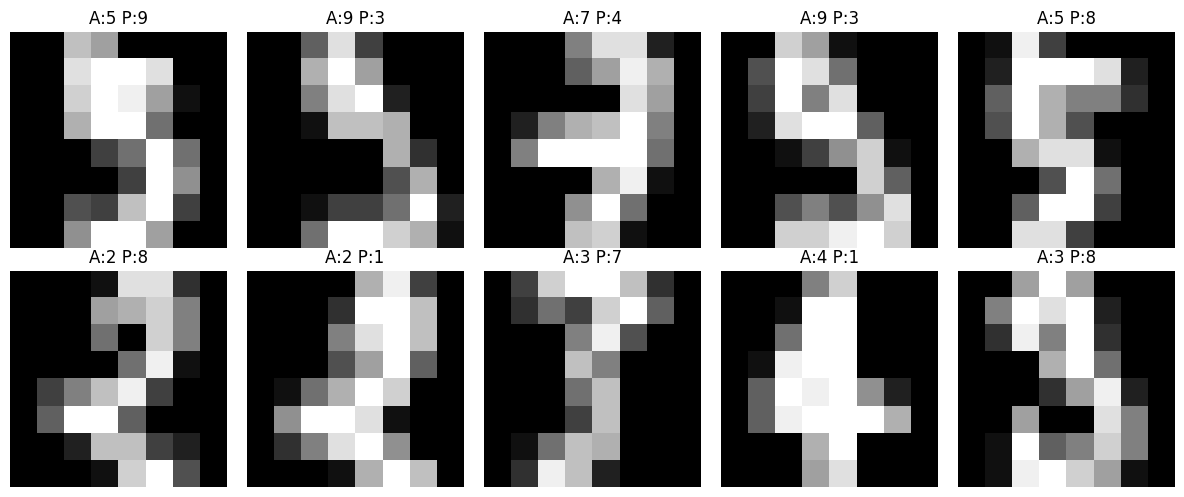

In [5]:
from sklearn.metrics import classification_report

print(classification_report(y_test, final_predictions))

# Show a few misclassified digit images to inspect where the model is making errors.
misclassified = [
    i for i, (actual, predicted) in enumerate(zip(y_test, final_predictions)) if actual != predicted
]

print(f"Misclassified sample count: {len(misclassified)}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for ax, idx in zip(axes, misclassified[:10]):
    img = X_test.iloc[idx].to_numpy().reshape(8, 8)
    actual = y_test.iloc[idx]
    predicted = final_predictions[idx]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"A:{actual} P:{predicted}")
    ax.axis('off')

for ax in axes[len(misclassified[:10]):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
